In [1]:
# ruff: noqa: N802, N803, N806, N815, N816

import matplotlib.pyplot as plt
import numpy as np

import archimedes as arc
from archimedes import quadrature as quad

# Quadrature

The `archimedes.quadrature` module containes a collection of methods for computing one-dimensional integrals.
The core algorithm is Gaussian-style weighted quadrature:

$$
\int_a^b f(x) \, w(x) \, dx \approx \sum_{i=1}^n w_i f(x_i),
$$

where $f(x)$ is the function to be integrated, $w(x)$ is a weight function (see below), and $\{x_i\}, \{w_i\}$ are the nodes and weights, which are uniquely determined by the family and order of the quadrature rule.

The most common quadrature family, [Gauss-Legendre quadrature](https://en.wikipedia.org/wiki/Gauss%E2%80%93Legendre_quadrature) uses a domain of $[-1, 1]$, with uniform weight $w(x) = 1$:

$$
\int_{-1}^{1} f(x) \, dx \approx \sum_{i=1}^n w_i f(x_i),
$$

which can be shifted to an arbitrary (finite) domain $[a, b]$ by rescaling the Gauss-Legendre nodes and weights by:

\begin{aligned}
x_i &\leftarrow \frac{b-a}{2} x_i + \frac{a+b}{2} \\
w_i &\leftarrow \frac{b-a}{2} w_i
\end{aligned}


## Quickstart

For integrating a finite function on a finite interval, you will usually want Gauss-Legendre quadrature.
In Archimedes, the high-level interface for this is to call the [`quadrature.integral`](#archimedes.quadrature.integral) function with the integration limits and the order of the quadrature approximation.

In [12]:
def f(x):
    return np.exp(x)


a, b = -3, 3  # Integration limits
J_ex = np.exp(b) - np.exp(a)  # Exact integral: e^b - e^a

# 5-point Gauss-Legendre quadrature rule
J_leg = quad.integral(f, a, b, n=5)

print(f"Exact integral:          {J_ex:.6f}")
print(f"Gauss-Legendre integral: {J_leg:.6f}")

Exact integral:          20.035750
Gauss-Legendre integral: 20.035578


Unlike [`scipy.integrate.quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html), this does not support adaptive integration with an error tolerance, nor does it support infinite or semi-infinite intervals.

However, it does support symbolic evaluation (including limite) and vector-valued integrands:

In [ ]:
# Differentiating the integral with respect to the limits of integration
def f(x):
    return np.exp(x)


@arc.compile
def integrate_f(a, b):
    return quad.integral(f, a, b, n=5)


dJ_da, dJ_db = arc.grad(integrate_f, argnums=(0, 1))(a, b)

# Analytical derivatives: dJ/da = -e^a, dJ/db = e^b
print(f"Analytical dJ/da: {-np.exp(a):.6f}, dJ/db: {np.exp(b):.6f}")
print(f"Computed dJ/da:   {dJ_da:.6f}, dJ/db: {dJ_db:.6f}")

Analytical dJ/da: -0.049787, dJ/db: 20.085537
Computed dJ/da:   -0.049547, dJ/db: 20.085125


In [22]:
# Vector-valued integrands
def f(x):
    return np.array([np.cos(x), np.sin(x)])


a, b = 0, np.pi / 2  # Integration limits
J_vec = quad.integral(f, a, b, n=3)

print("Analytical integral: [1, 1]")
print(f"Computed integral:   {J_vec}")

Analytical integral: [1, 1]
Computed integral:   [1.00000812 1.00000812]


This lets you easily compute derivatives "under the integral sign" using the Leibnitz rule:

Error: 3.2529317765771063e-06


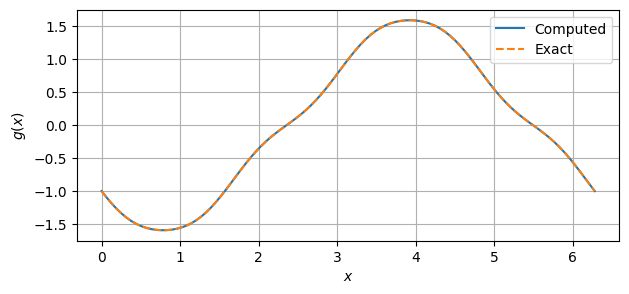

In [36]:
# https://en.wikipedia.org/wiki/Leibniz_integral_rule#Example_2:_Variable_limits


def f(x):
    return np.cosh(x**2)


def g(x):
    # Variable limits of integration
    a = np.sin(x)
    b = np.cos(x)
    # Compute integral using Gauss-Legendre quadrature
    return quad.integral(f, a, b, n=5)


# Compute g'(x) using automatic differentiation
dg_dx = arc.grad(g)

x = np.linspace(0, 2 * np.pi, 100)
dg = arc.vmap(dg_dx)(x)
dg_ex = -np.cosh(np.cos(x) ** 2) * np.sin(x) - np.cosh(np.sin(x) ** 2) * np.cos(x)

print(f"Error: {np.linalg.norm(dg - dg_ex)}")

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
ax.plot(x, dg, label="Computed")
ax.plot(x, dg_ex, "--", label="Exact")
ax.legend()
ax.grid()
ax.set_xlabel("$x$")
ax.set_ylabel("$g(x)$")
plt.show()

Every `QuadratureRule` has an associated `Measure`, which essentially combines a weight function $w(x)$ with a reference interval ("support") $[a, b]$.
For example, the Legendre measure (used by Gauss-Legendre, Gauss-Radau, Gauss-Lobatto, and Clenshaw-Curtis quadrature rules) has uniform weight $w(x) = 1$ and support $(-1, 1)$.
The (physicists') Hermite measure has weight $w(x) = e^{-x^2}$ on $(-\infty, \infty)$, and the Laguerre measure has weight $w(x) = e^{-x}$ on $(0, \infty)$.


Archimedes implements Gaussian quadrature using the `QuadratureRule` class, which includes methods:

- `integrate(f)`: Integrate `f(x)`
- `sum(fp)`: Directly perform the weighted sum `np.dot(weights, fp)` for known data
- `scaled_points()`/`scaled_weights()`: Compute the shifted/scaled nodes and weights for a different domain than the reference interval

Each quadrature rule 

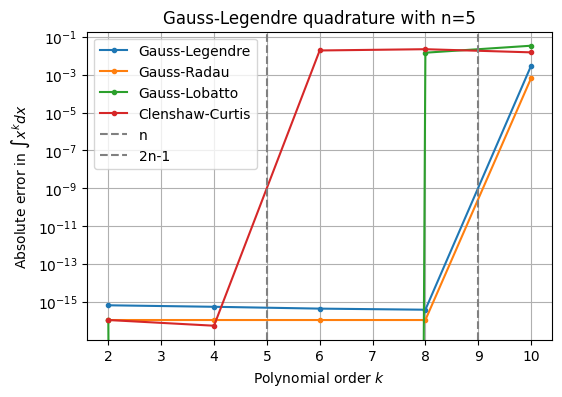

In [4]:
def integrate(k, n, rule):
    def f(x):
        return x**k

    return rule(n).integrate(f)


n = 5
k = np.arange(2, 2 * n + 2, 2)
# Exact integral: 0 for odd k, 2/k+1 for even k
J_ex = np.zeros_like(k, dtype=float)
J_ex = 2 / (k + 1)
J_leg = np.array([integrate(k_i, n, quad.gauss_legendre) for k_i in k])
J_rad = np.array([integrate(k_i, n, quad.gauss_radau) for k_i in k])
J_lob = np.array([integrate(k_i, n, quad.gauss_lobatto) for k_i in k])
J_cc = np.array([integrate(k_i, n, quad.clenshaw_curtis) for k_i in k])

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.semilogy(k, np.abs(J_leg - J_ex), ".-", label="Gauss-Legendre")
ax.semilogy(k, np.abs(J_rad - J_ex), ".-", label="Gauss-Radau")
ax.semilogy(k, np.abs(J_lob - J_ex), ".-", label="Gauss-Lobatto")
ax.semilogy(k, np.abs(J_cc - J_ex), ".-", label="Clenshaw-Curtis")
ax.axvline(n, color="grey", linestyle="--", label="n")
ax.axvline(2 * n - 1, color="grey", linestyle="--", label="2n-1")
ax.legend()
ax.set_xlabel("Polynomial order $k$")
ax.set_ylabel("Absolute error in $\\int x^k dx$")
ax.set_title(f"Gauss-Legendre quadrature with n={n}")
ax.grid()

In [5]:
# Domain mapping

n = 5
leg = quad.gauss_legendre(n)
# Exact integral: 2
print(f"Integral of sin(x) from 0 to pi: {leg.integrate(np.sin, 0, np.pi)}")

print(f"Reference nodes: {leg.nodes}")
print(f"Shifted nodes:   {leg.scaled_points(0, np.pi)}")

Integral of sin(x) from 0 to pi: 2.0000001102844713
Reference nodes: [-0.90617985 -0.53846931  0.          0.53846931  0.90617985]
Shifted nodes:   [0.14737235 0.72497071 1.57079633 2.41662194 2.9942203 ]


In [6]:
# Sum vs integral

n = 5
leg = quad.gauss_legendre(n)

domain = (0, np.pi)
xp = leg.scaled_points(*domain)


def f(x):
    return np.sin(x)


print(leg.integrate(f, *domain))
print(leg.sum(f(xp), *domain))

2.0000001102844713
2.0000001102844713


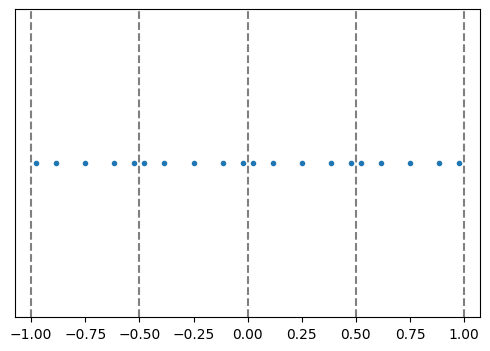

In [7]:
# Composite rules

n = 5
base_rule = quad.gauss_legendre(n)
breakpoints = np.linspace(-1, 1, 5)
rule = quad.composite(base_rule, breakpoints)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(rule.nodes, 0 * rule.nodes, ".")
for i in range(len(breakpoints)):
    ax.axvline(breakpoints[i], color="grey", linestyle="--")

ax.set_yticks([])

plt.show()

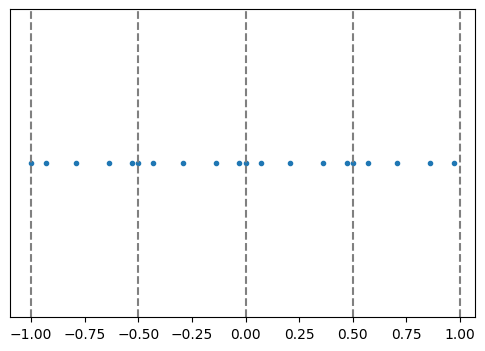

In [8]:
# Gauss-Radau for composite rules

n = 5
base_rule = quad.gauss_radau(n, endpoint="left")
breakpoints = np.linspace(-1, 1, 5)
rule = quad.composite(base_rule, breakpoints)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(rule.nodes, 0 * rule.nodes, ".")
for i in range(len(breakpoints)):
    ax.axvline(breakpoints[i], color="grey", linestyle="--")

ax.set_yticks([])
plt.show()

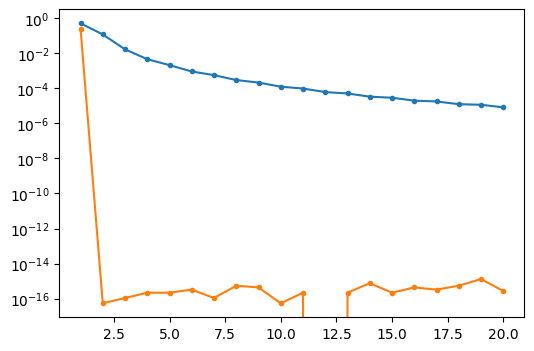

In [9]:
def f(x):
    return np.abs(x) ** 3


J_ex = 0.5  # Exact integral: 1/2

n = np.arange(1, 21)


# Plain Gauss-Legendre quadrature
def integrate(n):
    rule = quad.gauss_legendre(n)
    return rule.integrate(f)


# Composite: repeated Gauss-Legendre over subintervals
# Here, 2 subintervals: [-1, 0], [0, 1]
breakpoints = np.linspace(-1, 1, 3)


def integrate_composite(n):
    rule = quad.composite(quad.gauss_legendre(n), breakpoints)
    return rule.integrate(f)


J_leg = np.array([integrate(n_i) for n_i in n])
J_comp = np.array([integrate_composite(n_i) for n_i in n])

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.semilogy(n, np.abs(J_leg - J_ex), ".-", label="Gauss-Legendre")
ax.semilogy(n, np.abs(J_comp - J_ex), ".-", label="Composite Gauss-Legendre")

# x_plt = np.linspace(-1, 1, 101)
# fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# ax.plot(x_plt, f(x_plt), label="$|x|$")

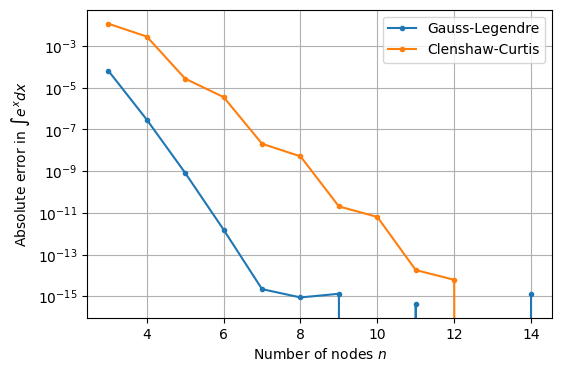

In [10]:
def f(x):
    return np.exp(x)


J_ex = np.exp(1) - np.exp(-1)  # Exact integral: e - 1/e

n = np.arange(3, 15)

J_leg = np.array([quad.gauss_legendre(n_i).integrate(f) for n_i in n])
J_cc = np.array([quad.clenshaw_curtis(n_i).integrate(f) for n_i in n])

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.semilogy(n, np.abs(J_leg - J_ex), ".-", label="Gauss-Legendre")
ax.semilogy(n, np.abs(J_cc - J_ex), ".-", label="Clenshaw-Curtis")
ax.legend()
ax.grid()
ax.set_xlabel("Number of nodes $n$")
ax.set_ylabel("Absolute error in $\\int e^x dx$")
plt.show()

# x_plt = np.linspace(-1, 1, 101)
# fig, ax = plt.subplots(1, 1, figsize=(6, 4))
# ax.plot(x_plt, f(x_plt), label="$|x|$")

In [11]:
# Vector-values integrand


def f(x):
    return np.stack([x, x**2, np.cos(x)])


print(quad.gauss_legendre(5).integrate(f))

[0.         0.66666667 1.68294197]



## Quadrature and orthogonal polynomials

The weight functions, reference domains, and node distributions can seem to be somewhat obscure at first.
These arise from a deep connection to _classical orthogonal polynomials_, and understanding why helps select the right family for an application.

### Integration by interpolation

The foundational idea of this kind of quadrature is that you approximate the data $f_i \equiv f(x_i)$ with a polynomial, and then integrate that polynomial exactly.
[Lagrange polynomials](https://en.wikipedia.org/wiki/Lagrange_polynomial) give you a minimum-degree polynomial that exactly interpolates a given set of data; in general $n$ data points can be exactly interpolated by an $n-1$-degree Lagrange polynomial.

In other words, if the function $f$ happens to be an $n-1$-degree polynomial, you can integrate it exactly on any set of $n$ nodes by constructing a Lagrange interpolating polynomial and integrating it analytically.
The weights are the combination of the weight function $w(x)$ evaluated at the nodes, and the (linear, pre-computable) contribution of the Lagrange polynomial from that node to the integral.

Of course, if $f$ was a polynomial we could just integrate it analytically anyway, but smooth functions can be accurately approximated with polynomials (and non-smooth functions with piecewise-polynomials), so the exactness of the polynomial degree roughly gives us the accuracy of the method for arbitrary functions.

The genius of Gaussian quadrature is to choose the node positions carefully to get much higher accuracy.
For the Gauss-Legendre method, by adding $n$ additional degrees of freedom to the algebraic problem, we boost the accuracy from $n-1$ to $2n - 1$.

Suppose $f(x)$ is a polynomial of degree $\leq 2n - 1$, and we will be interpolating at roots $x_i$.
We can construct a polynomial $q_n(x) \equiv \prod_{i=1}^n (x - x_i)$ and do [polynomial long division](https://en.wikipedia.org/wiki/Polynomial_long_division) to decompose into the node polynomial $q_n(x)$, a quotient $p(x)$, and the remainder $r(x)$ (degrees $n$, $\leq n-1$, and $\leq n-1$, respectively):

$$
f(x) = q_n(x) p(x) + r(x).
$$

We don't know what $p(x)$ and $r(x)$ are here; they're arbitrary polynomials used to derive the conditions on the selection of roots.

If we apply the quadrature rule $\sum_{i=1}^n w_i f(x_i)$ to this, by construction $q_n(x_i) = 0$, so

$$
\sum_{i=1}^n w_i f(x_i) = \sum_{i=1}^n w_i r(x_i)
$$

If the weights are chosen as above, then since $r(x)$ has degree $\leq n - 1$ this integral is exact over $r$, so 

$$
\sum_{i=1}^n w_i f(x_i) = \int_a^b w(x) \, r(x) \, dx.
$$

In order for this to *also* equal the weighted integral of $f(x)$, the additional contribution from $q_n(x) p(x)$ has to vanish for *any* polynomial $p(x)$ with degree $\leq n - 1$:

$$
\int_a^b w(x) \, q_n(x) \, p(x) \, dx = 0.
$$

This is exactly the defining property of [orthogonal polynomials](https://en.wikipedia.org/wiki/Orthogonal_polynomials).

### Orthogonal polynomials

Don't go read that Wikipedia page; it's full of terms like "Lebesgue–Stieltjes integrals".
The important thing for Gaussian quadrature is that given a weight function and a domain, you can derive a family of polynomials such that the $n$-th polynomial is orthogonal to all $n-1$ polynomials in that family with respect to that weight, exactly the property Gauss identifies for optimizing accuracy of the quadrature rule:

$$
\int_a^b w(x) \, q_i(x) \, q_j(x) \, dx = 0, \qquad i \neq j
$$

Since any $n-1$-degree polynomial can be represented by a linear combination of $q_i(x)$, $i = 0, 1, \dots, n-1$, the quotient term from polynomial division is guaranteed to vanish.

The upshot is that **if we choose the quadrature nodes to be the roots of the appropriate orthogonal polynomial, then we get optimal quadrature accuracy**.
The "appropriate" polynomial depends on the weight function and the domain, commonly:

| Weight $w(x)$ | Domain | Orthogonal polynomials | Quadrature scheme |
|---|---|---|---|
| $1$ | $[-1,1]$ | [Legendre](https://en.wikipedia.org/wiki/Legendre_polynomials) | [Gauss–Legendre](https://en.wikipedia.org/wiki/Gauss%E2%80%93Legendre_quadrature) |
| $(1-x)^\alpha(1+x)^\beta$ | $[-1,1]$ | [Jacobi](https://en.wikipedia.org/wiki/Jacobi_polynomials) | [Gauss-Jacobi](https://en.wikipedia.org/wiki/Gauss%E2%80%93Jacobi_quadrature) |
| $e^{-x^2}$ | $(-\infty,\infty)$ | [Hermite](https://en.wikipedia.org/wiki/Hermite_polynomials) | [Gauss–Hermite](https://en.wikipedia.org/wiki/Gauss%E2%80%93Hermite_quadrature) |
| $e^{-x}$ | $[0,\infty)$ | [Laguerre](https://en.wikipedia.org/wiki/Laguerre_polynomials) | [Gauss–Laguerre](https://en.wikipedia.org/wiki/Gauss%E2%80%93Laguerre_quadrature) |

The domains (but not their finite-ness) can be adjusted by shifting and scaling the quadrature weights and nodes.

Once the nodes $x_i$ are determined, the weights are again the combination of the weight function values $w(x_i)$ and the contribution to the final integral from the associated Lagrange polynomial.

### Constrained quadrature schemes

The basic Gaussian quadrature methods place $n$ nodes to be the roots of the $n$-th order orthogonal polynomial from the appropriate family.
However, these roots don't inherently include the endpoints of the interval.

Alternatively, we can derive _constrained_ quadrature families that include one or both endpoints; the tradeoff is 1-2 fewer degrees of freedom for the polynomial interpolation and corresponding loss of exactness in polynomial quadrature:

- **Gauss-Legendre rules**: Do not include endpoints - exact to order $2n - 1$
- **Gauss-Radau rules**: Include the left or right endpoint (configurable) - exact to order $2n - 2$
- **Gauss-Lobatto rules**: Include both endpoints - exact to order $2n - 3$.



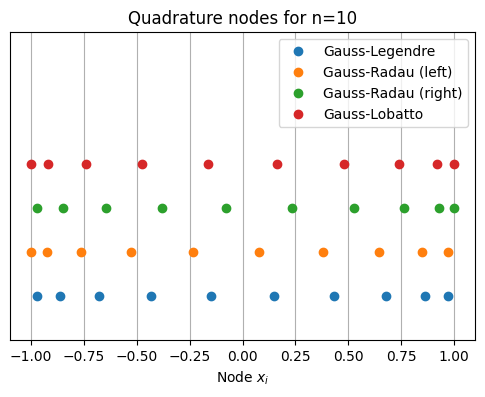

In [12]:
n = 10
leg = quad.gauss_legendre(n)
rad_left = quad.gauss_radau(n, endpoint="left")
rad_right = quad.gauss_radau(n, endpoint="right")
lob = quad.gauss_lobatto(n)
# cc = quad.clenshaw_curtis(n)

zero = np.zeros_like(leg.nodes)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(leg.nodes, zero, "o", label="Gauss-Legendre")
ax.plot(rad_left.nodes, zero + 1, "o", label="Gauss-Radau (left)")
ax.plot(rad_right.nodes, zero + 2, "o", label="Gauss-Radau (right)")
ax.plot(lob.nodes, zero + 3, "o", label="Gauss-Lobatto")
# ax.plot(cc.nodes, zero + 4, 'o', label="Clenshaw-Curtis")
ax.set_xlabel("Node $x_i$")
ax.set_title(f"Quadrature nodes for n={n}")
ax.legend()
ax.set_ylim(-1, 6)
ax.grid()
ax.set_yticks([])
plt.show()


These can be useful for different applications; Gauss-Radau gives useful stability properties for implicit ODE solvers, both Gauss-Radau and Gauss-Lobatto are commonly used in pseudospectral optimal control methods, and Gauss-Lobatto is widely used for high-order spectral element methods.

The schemes themselves are derived similarly to the Gauss-Legendre case, but fixing one of the roots in the polynomial division, e.g. $q_n(x) = (x - a) q_{n-1}(x)$ for Radau.
This amounts to a different weight in the orthogonality requirement and therefore a different member of the orthogonal polynomial family.
For Gauss-Radau with an endpoint at $x = a$ and original weight $w(x) = 1$, the orthogonality condition becomes:

$$
\int_a^b (x - a) \, q_i(x) \, q_j(x) \, dx = 0, \qquad i \neq j
$$

That is, the nodes must be placed at the roots of the polynomials that are orthogonal with respect to this inner product with weight $(x - a)$.